# 1. lOGISTIC REGRESSION
is used for CLASSIFICATION ONLY

It will calculate probabilties by fitting sigmoid curve.

In [1]:
from warnings import filterwarnings

filterwarnings("ignore")

# Step -1 Data ingestion

In [2]:
import pandas as pd

df = pd.read_csv("iris.csv")

# Step - 2 Data cleaning
Target feature - species which is categorical

In [3]:
df["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

### As number of classes are more than 2 , its multiclass classification problem

In [4]:
# remove duplicate
df = df.drop_duplicates(keep="first").reset_index(drop=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
 4   species       149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


# Step 3 - Separate X and Y

In [6]:
X = df.drop(columns=["species"])

In [7]:
Y = df[["species"]]

In [8]:
Y

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
144,virginica
145,virginica
146,virginica
147,virginica


In [9]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
144,6.7,3.0,5.2,2.3
145,6.3,2.5,5.0,1.9
146,6.5,3.0,5.2,2.0
147,6.2,3.4,5.4,2.3


# Step 4 - Apply preprocessing on X

In [11]:
X.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [ ]:
num_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()).set_output(
    transform="pandas"
)

In [14]:
X_pre = num_pipe.fit_transform(X)

In [15]:
X_pre.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.898033,1.012401,-1.333255,-1.308624
1,-1.139562,-0.137353,-1.333255,-1.308624
2,-1.381091,0.322549,-1.390014,-1.308624
3,-1.501855,0.092598,-1.276496,-1.308624
4,-1.018798,1.242352,-1.333255,-1.308624


In [16]:
num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


# Step -5 Train Test Split 

In [28]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    X_pre, Y, test_size=0.33, random_state=42
)

In [29]:
xtrain.head()

,sepal_length,sepal_width,petal_length,petal_width
95,-0.173447,-0.137353,0.255985,0.007064
104,0.792668,-0.137353,1.164122,1.322752
66,-0.294211,-0.137353,0.426261,0.401770
0,-0.898033,1.012401,-1.333255,-1.308624
141,1.275726,0.092598,0.766812,1.454321


In [30]:
ytrain.head()

,species
95,versicolor
104,virginica
66,versicolor
0,setosa
141,virginica



# Step 6 model building 

In [31]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=21)
log_model.fit(xtrain, ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
log_model.intercept_

array([-0.28141613,  1.79490819, -1.51349205])

In [32]:
log_model.score(xtrain, ytrain)

0.9494949494949495

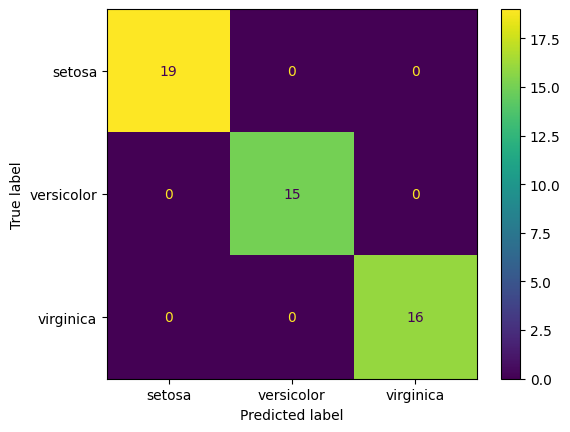

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(log_model, xtest, ytest)

In [36]:
ypred_train = log_model.predict(xtrain)
ypred_test = log_model.predict(xtest)

In [38]:
ypred_train[0:3]

array(['versicolor', 'virginica', 'versicolor'], dtype=object)

In [39]:
ypred_test[0:3]

array(['versicolor', 'setosa', 'virginica'], dtype=object)

In [40]:
ytest.head()

,species
73,versicolor
18,setosa
117,virginica
78,versicolor
76,versicolor


In [42]:
prob_test = log_model.predict_proba(xtest).round(4)
prob_test[0:5]

array([[0.0135, 0.8531, 0.1334],
       [0.9666, 0.0334, 0.    ],
       [0.    , 0.0212, 0.9788],
       [0.0154, 0.7319, 0.2528],
       [0.0025, 0.712 , 0.2855]])

In [43]:
from sklearn.metrics import classification_report

print(classification_report(ytest, ypred_test))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [45]:
from sklearn.metrics import f1_score

f1_score(ytest, ypred_test, average="macro")

1.0

In [47]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(log_model, xtrain, ytrain, cv=5, scoring="f1_macro")

In [48]:
scores

array([0.95213675, 0.80952381, 0.90277778, 1.        , 0.94747475])

In [50]:
scores.mean().round(4)

np.float64(0.9224)

# from above results its clear that the model can be used for out of sample prediction 

### Logistic regressiion - out of sample prediction 

In [51]:
xnew = pd.read_csv("iris_sample.csv")

In [52]:
num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [53]:
Xnew_pre = num_pipe.transform(xnew)

In [54]:
Xnew_pre

,sepal_length,sepal_width,petal_length,petal_width
0,-0.414976,-1.287108,0.142468,0.138633
1,1.275726,0.092598,0.766812,1.454321
2,-0.898033,-1.287108,-0.425118,-0.124505
3,-1.743384,-0.367304,0.312744,-1.308624
4,0.068082,-0.137353,0.766812,0.796477
5,-0.414976,1.012401,-1.390014,-1.308624
6,-0.294211,-0.137353,-0.084566,0.138633
7,0.792668,-0.137353,0.823571,1.059614
8,-0.656505,1.472303,-1.276496,-1.308624
9,-0.898033,0.782450,-1.276496,0.138633


In [55]:
preds = log_model.predict(Xnew_pre)

In [56]:
preds

array(['versicolor', 'virginica', 'versicolor', 'setosa', 'virginica',
       'setosa', 'versicolor', 'virginica', 'setosa', 'setosa',
       'versicolor', 'versicolor', 'virginica', 'versicolor', 'virginica'],
      dtype=object)

In [57]:
probs = log_model.predict_proba(Xnew_pre).round(4)

In [58]:
probs

array([[2.350e-02, 8.781e-01, 9.830e-02],
       [1.000e-04, 6.640e-02, 9.335e-01],
       [1.338e-01, 8.540e-01, 1.220e-02],
       [6.598e-01, 3.396e-01, 6.000e-04],
       [4.600e-03, 3.198e-01, 6.756e-01],
       [9.611e-01, 3.890e-02, 0.000e+00],
       [1.295e-01, 8.321e-01, 3.840e-02],
       [6.000e-04, 1.569e-01, 8.426e-01],
       [9.824e-01, 1.760e-02, 0.000e+00],
       [8.827e-01, 1.170e-01, 3.000e-04],
       [2.240e-02, 8.939e-01, 8.360e-02],
       [3.430e-02, 9.407e-01, 2.500e-02],
       [0.000e+00, 1.690e-02, 9.831e-01],
       [4.000e-03, 6.502e-01, 3.458e-01],
       [7.000e-04, 4.716e-01, 5.277e-01]])

In [59]:
log_model.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [60]:
xnew["species_predicter"] = preds
xnew[log_model.classes_] = probs

In [61]:
xnew

,sepal_length,sepal_width,petal_length,petal_width,species_predicter,setosa,versicolor,virginica
0,5.5,2.5,4.0,1.3,versicolor,0.0235,0.8781,0.0983
1,6.9,3.1,5.1,2.3,virginica,0.0001,0.0664,0.9335
2,5.1,2.5,3.0,1.1,versicolor,0.1338,0.8540,0.0122
3,4.4,2.9,NaN,0.2,setosa,0.6598,0.3396,0.0006
4,5.9,3.0,5.1,1.8,virginica,0.0046,0.3198,0.6756
5,5.5,3.5,1.3,0.2,setosa,0.9611,0.0389,0.0000
6,5.6,NaN,3.6,1.3,versicolor,0.1295,0.8321,0.0384
7,6.5,3.0,5.2,2.0,virginica,0.0006,0.1569,0.8426
8,5.3,3.7,1.5,0.2,setosa,0.9824,0.0176,0.0000
9,5.1,3.4,1.5,NaN,setosa,0.8827,0.1170,0.0003


In [62]:
xnew.to_csv("logistic_results.csv", index=False)

# Save model object for Logistic Regression

In [64]:
import joblib as jl

In [65]:
num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [66]:
log_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
jl.dump(num_pipe, "preprocessor.joblib")

['preprocessor.joblib']

In [68]:
jl.dump(log_model, "logistic_regression_model.joblib")

['logistic_regression_model.joblib']

In [69]:
m = jl.load("preprocessor.joblib")

In [71]:
l = jl.load("logistic_regression_model.joblib")

In [72]:
m

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [74]:
l

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'



# Decision Tree Classification 

In [75]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(
    max_depth=1,
    min_samples_split=3,
    min_samples_leaf=5,
    criterion="entropy",
    random_state=42,
)

In [76]:
model2.fit(xtrain, ytrain)

,criterion,'entropy'
,splitter,'best'
,max_depth,1
,min_samples_split,3
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [78]:
model2.score(xtrain, ytrain)

0.6666666666666666

# Hyper parameter tuning for decision tree

In [79]:
params = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [5, 6, 7, 8],
    "min_samples_leaf": [5, 6, 7, 8],
    "criterion": ["gini", "entropy"],
}

In [81]:
from sklearn.model_selection import RandomizedSearchCV

model = DecisionTreeClassifier(random_state=42)
rscv_dtc = RandomizedSearchCV(
    model, param_distributions=params, cv=5, scoring="f1_macro", random_state=42
)

In [82]:
rscv_dtc.fit(xtrain, ytrain)

,estimator,DecisionTreeC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [5, 6, ...], 'min_samples_split': [5, 6, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [83]:
rscv_dtc.best_params_

{'min_samples_split': 8,
 'min_samples_leaf': 5,
 'max_depth': 5,
 'criterion': 'gini'}

In [84]:
rscv_dtc.best_score_

np.float64(0.9223826173826174)

In [85]:
best_dtc = rscv_dtc.best_estimator_

In [86]:
best_dtc

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,8
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Evaluation the best dtc model 

In [87]:
best_dtc.score(xtrain, ytrain)

0.9393939393939394

In [88]:
best_dtc.score(xtest, ytest)

1.0

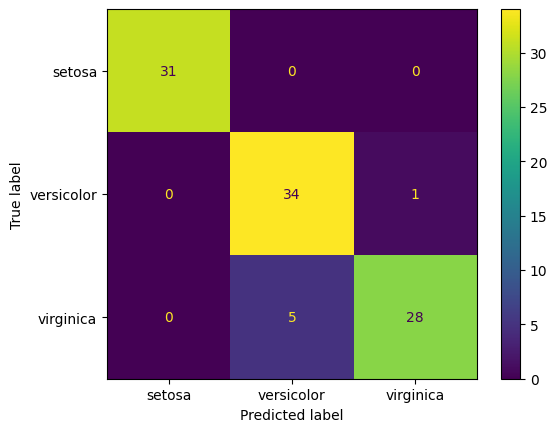

In [90]:
ConfusionMatrixDisplay.from_estimator(best_dtc, xtrain, ytrain)

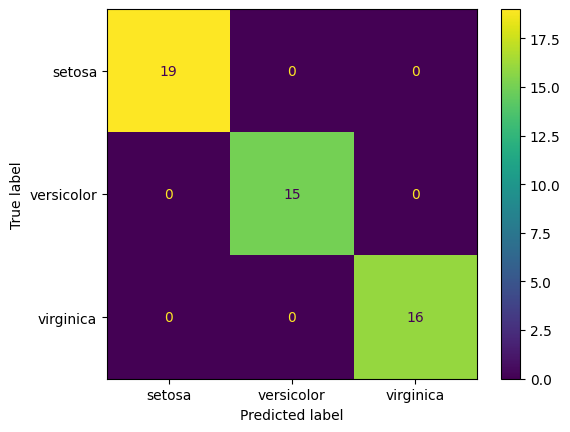

In [92]:
ConfusionMatrixDisplay.from_estimator(best_dtc, xtest, ytest)

In [93]:
ypred_test2 = best_dtc.predict(xtest)

In [94]:
ypred_test2[0:3]

array(['versicolor', 'setosa', 'virginica'], dtype=object)

In [96]:
print(classification_report(ytest, ypred_test2))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



# PLOT THE DECISION TREE

In [98]:
xtrain.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

In [99]:
best_dtc.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [100]:
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree

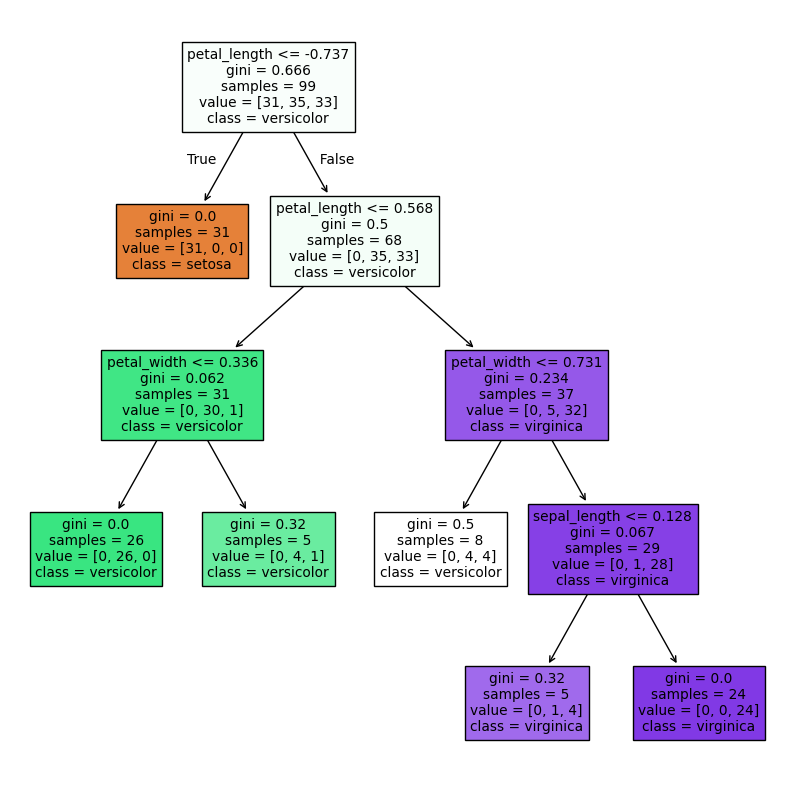

In [101]:
plt.figure(figsize=(10, 10))
plot_tree(
    best_dtc, feature_names=xtrain.columns, class_names=best_dtc.classes_, filled=True
)
plt.show()

# Feature importance 

In [102]:
xtrain.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

In [103]:
best_dtc.feature_importances_

array([0.00563759, 0.        , 0.94236752, 0.05199489])

In [104]:
imp = pd.Series(best_dtc.feature_importances_, index=xtrain.columns)

In [106]:
imp.sort_values(ascending=False)

petal_length    0.942368
petal_width     0.051995
sepal_length    0.005638
sepal_width     0.000000
dtype: float64

<Axes: title={'center': 'Feature Importance'}>

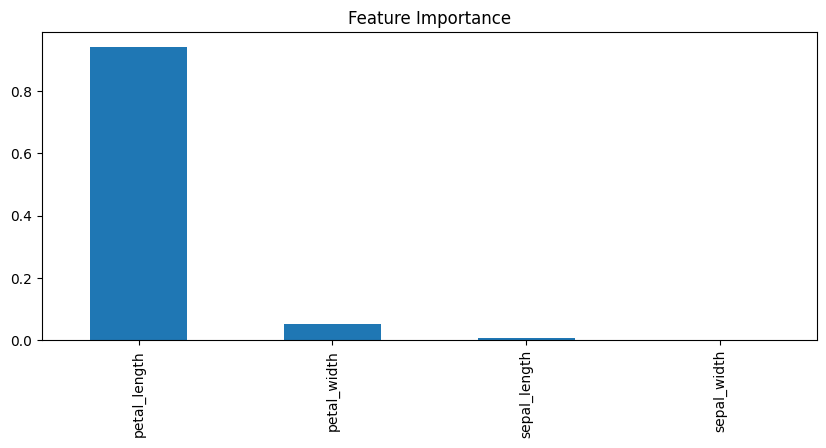

In [108]:
imp.sort_values(ascending=False).plot(
    kind="bar", figsize=(10, 4), title="Feature Importance"
)

# Out of sample prediction for decision trees

In [109]:
Xnew_pre

,sepal_length,sepal_width,petal_length,petal_width
0,-0.414976,-1.287108,0.142468,0.138633
1,1.275726,0.092598,0.766812,1.454321
2,-0.898033,-1.287108,-0.425118,-0.124505
3,-1.743384,-0.367304,0.312744,-1.308624
4,0.068082,-0.137353,0.766812,0.796477
5,-0.414976,1.012401,-1.390014,-1.308624
6,-0.294211,-0.137353,-0.084566,0.138633
7,0.792668,-0.137353,0.823571,1.059614
8,-0.656505,1.472303,-1.276496,-1.308624
9,-0.898033,0.782450,-1.276496,0.138633


In [113]:
preds1 = best_dtc.predict(Xnew_pre)

In [114]:
preds1

array(['versicolor', 'virginica', 'versicolor', 'versicolor', 'virginica',
       'setosa', 'versicolor', 'virginica', 'setosa', 'setosa',
       'versicolor', 'versicolor', 'virginica', 'versicolor',
       'versicolor'], dtype=object)